### import section

In [103]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

### Data Loaded

In [104]:
df = pd.read_csv("Customer Purchase Dataset/online_shoppers_intention.csv")

print(df)

       Administrative  Administrative_Duration  Informational  \
0                   0                      0.0              0   
1                   0                      0.0              0   
2                   0                      0.0              0   
3                   0                      0.0              0   
4                   0                      0.0              0   
...               ...                      ...            ...   
12325               3                    145.0              0   
12326               0                      0.0              0   
12327               0                      0.0              0   
12328               4                     75.0              0   
12329               0                      0.0              0   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                         0.0               1                 0.000000   
1                         0.0               2                64.000000 

### Preprocessing

#### Dataset Information Check

In [105]:
print("Dataset Shape:", df.shape)

Dataset Shape: (12330, 18)


In [106]:
print(df.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')


In [107]:
print(df.head())

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         0.0   Feb   

In [108]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [109]:
print(df.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [110]:
print(df["Revenue"].value_counts())

Revenue
False    10422
True      1908
Name: count, dtype: int64


In [111]:
print(df.dtypes)

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object


### Encode

In [112]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

##### Month encode

In [113]:
print(df["Month"].unique())

<ArrowStringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str


In [114]:
df["Month"] = encoder.fit_transform(df["Month"])


In [115]:
month_mapping = {
    month: int(code)
    for month, code in zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
}

print(month_mapping)

{'Aug': 0, 'Dec': 1, 'Feb': 2, 'Jul': 3, 'June': 4, 'Mar': 5, 'May': 6, 'Nov': 7, 'Oct': 8, 'Sep': 9}


In [116]:
print(df["Month"].head(10))

0    2
1    2
2    2
3    2
4    2
5    2
6    2
7    2
8    2
9    2
Name: Month, dtype: int64


##### VisitorType encode

In [117]:
print(df["VisitorType"].unique())

<ArrowStringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str


In [118]:
df["VisitorType"] = encoder.fit_transform(df["VisitorType"])

In [119]:
visitor_mapping = {
    visitor: int(code)
    for visitor, code in zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
}

print(visitor_mapping)

{'New_Visitor': 0, 'Other': 1, 'Returning_Visitor': 2}


In [120]:
print(df["VisitorType"].head(10))

0    2
1    2
2    2
3    2
4    2
5    2
6    2
7    2
8    2
9    2
Name: VisitorType, dtype: int64


##### Weekend encode

In [121]:
print(df["Weekend"].unique())

[False  True]


In [122]:
df["Weekend"] = encoder.fit_transform(df["Weekend"])

In [123]:
weekend_mapping = {
    value: int(code)
    for value, code in zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
}

print(weekend_mapping)

{np.False_: 0, np.True_: 1}


In [124]:
print(df["Weekend"].head(10))

0    0
1    0
2    0
3    0
4    1
5    0
6    0
7    1
8    0
9    0
Name: Weekend, dtype: int64


##### Revenue encode

In [125]:
print(df["Revenue"].unique())

[False  True]


In [126]:
df["Revenue"] = encoder.fit_transform(df["Revenue"])

In [127]:
revenue_mapping = {
    value: int(code)
    for value, code in zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
}

print(revenue_mapping)

{np.False_: 0, np.True_: 1}


In [128]:
print(df["Revenue"] .head(10))

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: Revenue, dtype: int64


### Feature (X) and Target (y)

In [129]:
X = df.drop("Revenue", axis=1)

y = df["Revenue"]

In [130]:
print(X.head())

print(y.head())

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay  Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0      2                 1   
1         0.00       0.10         0.0         0.0      2

In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [132]:
print(X_train.shape)

print(X_test.shape)

(9864, 17)
(2466, 17)


#### Model Create

In [133]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [134]:
model.fit(X_train, y_train)

C:\Users\khadiza.akter\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Prediction

In [135]:
y_pred = model.predict(X_test)

In [136]:
print(y_pred[:20])

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


In [137]:
print(y_test.head(20).values)

[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


#### Accuracy Score

In [138]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8686131386861314


#### Confusion Matrix

In [139]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2009   46]
 [ 278  133]]


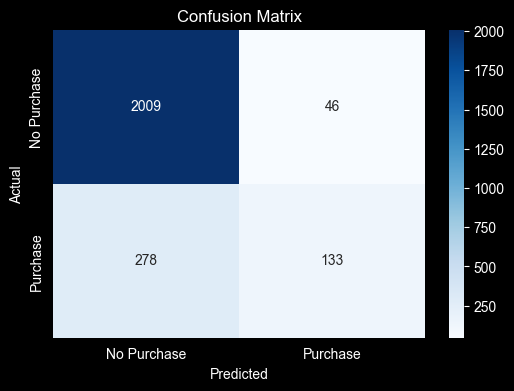

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Purchase', 'Purchase'],
    yticklabels=['No Purchase', 'Purchase']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [141]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93      2055
           1       0.74      0.32      0.45       411

    accuracy                           0.87      2466
   macro avg       0.81      0.65      0.69      2466
weighted avg       0.86      0.87      0.85      2466



#### Decision Tree

In [142]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [143]:
# প্রথমে root node দেখো
root_index = dt_model.tree_.feature[0]

root_feature = X.columns[root_index]

print("Root Node:", root_feature)

Root Node: PageValues


In [144]:
# Root node এর split value দেখো
root_threshold = dt_model.tree_.threshold[0]

print("Root Feature:", root_feature)

print("Root Threshold:", root_threshold)

Root Feature: PageValues
Root Threshold: 0.9915753602981567


In [145]:
dt_pred = dt_model.predict(X_test)

In [146]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8580697485806975


In [147]:
dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

[[1877  178]
 [ 172  239]]


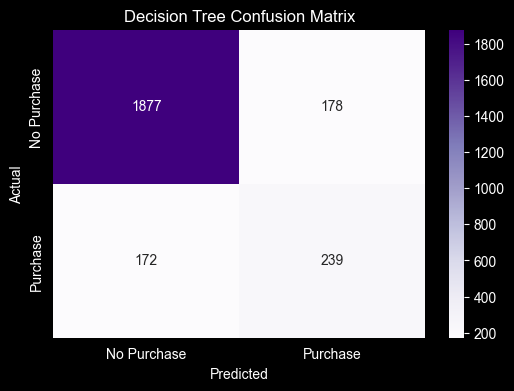

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Purchase', 'Purchase'],
    yticklabels=['No Purchase', 'Purchase']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

#### Random Forest

* Multiple tree use করে
* Better pattern detect করে
* Buyer prediction improve করতে পারে
* Overfitting কমায়

In [149]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [150]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [151]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8965936739659367


In [152]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2055
           1       0.76      0.55      0.64       411

    accuracy                           0.90      2466
   macro avg       0.84      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466



In [153]:
y_pred_rf = rf_model.predict(X_test)

In [154]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, y_pred_rf)

print(rf_cm)

[[1985   70]
 [ 185  226]]


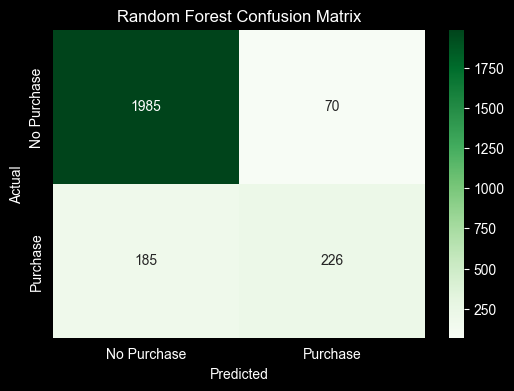

In [155]:
plt.figure(figsize=(6,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Purchase', 'Purchase'],
    yticklabels=['No Purchase', 'Purchase']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [156]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3 model prediction
models = {
    "Logistic Regression": y_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

results = []

for model_name, pred in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred) * 100,
        "Precision": precision_score(y_test, pred) * 100,
        "Recall": recall_score(y_test, pred) * 100,
        "F1 Score": f1_score(y_test, pred) * 100
    })

comparison_df = pd.DataFrame(results)

print(comparison_df)

                 Model   Accuracy  Precision     Recall   F1 Score
0  Logistic Regression  86.861314  74.301676  32.360097  45.084746
1        Decision Tree  85.806975  57.314149  58.150852  57.729469
2        Random Forest  89.659367  76.351351  54.987835  63.932107


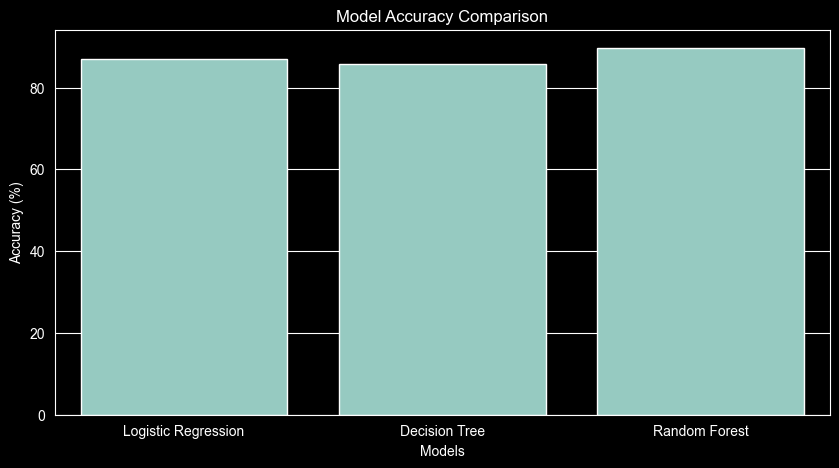

In [157]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.show()